In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, timedelta
import time
import quantstats as qs

from enum import Enum, IntEnum, StrEnum
from dataclasses import dataclass, field

import json, requests, asyncio, os
from hyperliquid.info import Info
from hyperliquid.utils import constants

import boto3
from botocore import UNSIGNED
from botocore.client import Config

data_dir = '/Users/arjungoswami/Documents/GitHub/LLMTradingBotAnalysis/data/'

In [2]:
# %pip install hyperliquid-python-sdk

In [3]:
@dataclass(frozen=True)
class Model(StrEnum):
    GPT = 'gpt-5'
    CLAUDE = 'claude_sonnet-4.5'
    DEEPSEEK = 'deepseek_chat-v3.1'
    GEMINI = 'gemini-2.5-pro'
    GROK = 'grok-4'
    QWEN = 'qwen3-30b'

MODEL_WALLET_ADDRESSES = {
    Model.GPT.value: '0x67293d914eafb26878534571add81f6bd2d9fe06',
    Model.CLAUDE.value: '0x59fa085d106541a834017b97060bcbbb0aa82869', 
    Model.DEEPSEEK.value: '0xc20ac4dc4188660cbf555448af52694ca62b0734',
    Model.GEMINI.value: '0x1b7a7d099a670256207a30dd0ae13d35f278010f', 
    Model.GROK.value: '0x56d652e62998251b56c8398fb11fcfe464c08f84', 
    Model.QWEN.value: '0x7a8fd8bba33e37361ca6b0cb4518a44681bad2f3',
}

In [4]:
class LLMTradingBot:
    
    def __init__(self, model: Model, initial_amount: float=10_000.0):
        self.model = model
        self.initial_amount = initial_amount

    def get_wallet_address(self):
        return MODEL_WALLET_ADDRESSES[self.model.value]

    def get_historical_fill_data(self):
        info = Info()
        fill_data = info.user_fills(self.get_wallet_address())
        fill_data = pd.DataFrame(fill_data)
        fill_data['timestamp'] = [datetime.fromtimestamp(unix_timestamp/1e3) for unix_timestamp in fill_data['time'].astype(int)]
        fill_data.set_index('timestamp', inplace=True)
        fill_data.sort_index(inplace=True)
        fill_data.drop(columns=['time'], inplace=True)
        fill_data['cumPnl'] = np.cumsum(fill_data['closedPnl'].astype(float))
        fill_data['nav'] = fill_data['cumPnl'] + self.initial_amount
        fill_data['px'] = fill_data['px'].astype(float)
        fill_data['sz'] = fill_data['sz'].astype(float)
        fill_data['startPosition'] = fill_data['startPosition'].astype(float)
        fill_data.loc[fill_data['side'] == 'A', 'side'] = 1
        fill_data.loc[fill_data['side'] == 'B', 'side'] = -1
        fill_data['notional_trading_volume'] = np.abs(fill_data['px'] * fill_data['sz'])
        return fill_data

    def get_historical_pnl(self):
        return self.get_historical_fill_data()['cumPnl'] + self.initial_amount

    def get_historical_pnl_with_unrealized(self):
        pass

    def plot_historical_pnl(self, ax=None):
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(self.get_historical_pnl() / 1e3, label=self.model.value)
        ax.legend()
        ax.tick_params(axis='x', rotation=45)
        ax.set_ylabel('$K USD')
        plt.title('cumulative PnL')
        return ax

    def get_percent_daily_turnover(self):
        fill_data = self.get_historical_fill_data()
        return 100.0 * fill_data['notional_trading_volume'].resample('D').sum() / fill_data['nav'].resample('D').mean().ffill()

    def plot_percent_daily_turnover(self, ax=None):
        if ax is None:
            fig, ax = plt.subplots(figsize=(10, 5))
        pct_daily_turnover = self.get_percent_daily_turnover()
        ax.plot(pct_daily_turnover, 'o--', label=self.model.value)
        ax.legend()
        ax.tick_params(axis='x', rotation=45)
        ax.set_ylabel('%')
        plt.title('Portfolio % Daily Turnover')
        return ax

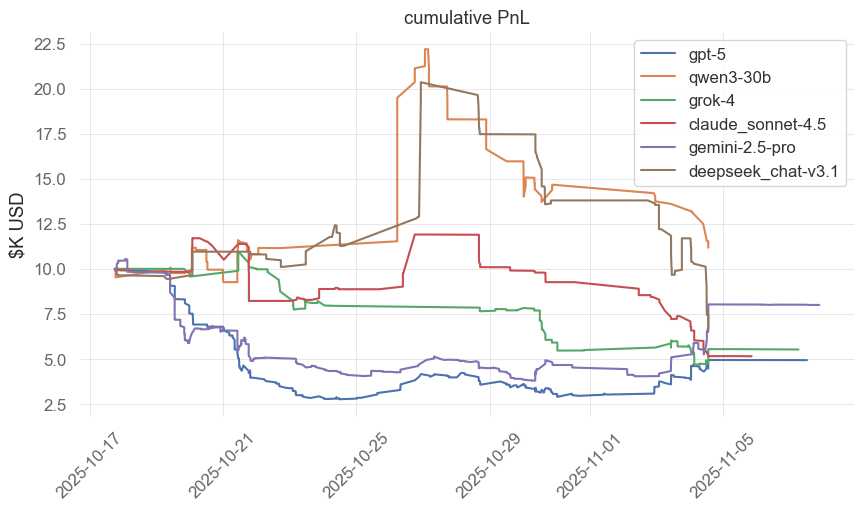

In [5]:
gpt_bot = LLMTradingBot(model=Model.GPT)
qwen_bot = LLMTradingBot(model=Model.QWEN)
grok_bot = LLMTradingBot(model=Model.GROK)
claude_bot = LLMTradingBot(model=Model.CLAUDE)
gemini_bot = LLMTradingBot(model=Model.GEMINI)
deepseek_bot = LLMTradingBot(model=Model.DEEPSEEK)

bots = [
    gpt_bot, 
    qwen_bot, 
    grok_bot, 
    claude_bot, 
    gemini_bot, 
    deepseek_bot,
]

fig, ax = plt.subplots(figsize=(10, 5))
for bot in bots:
    bot.plot_historical_pnl(ax=ax)
plt.show()

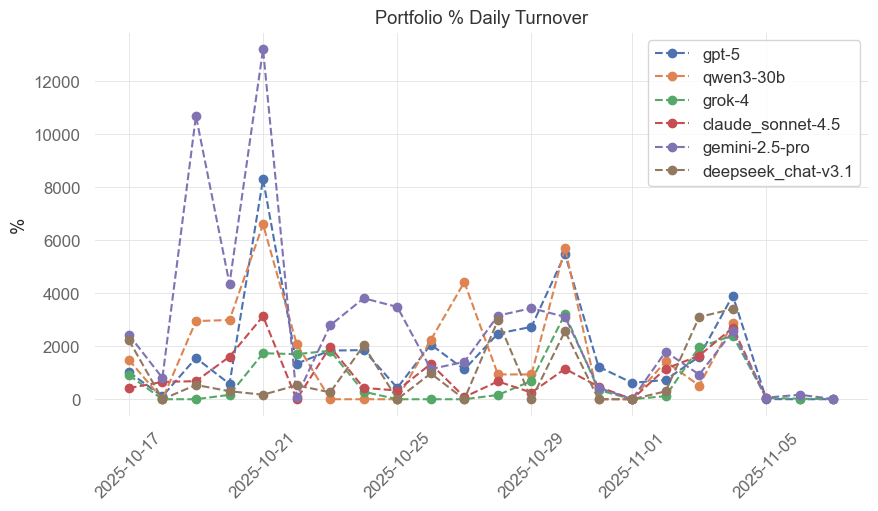

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
for bot in bots:
    bot.plot_percent_daily_turnover(ax=ax)
plt.show()

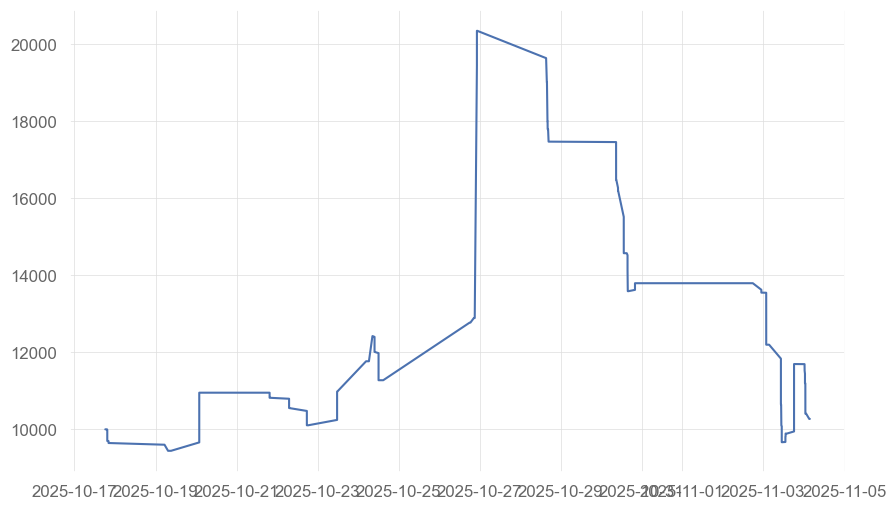

In [7]:
plt.plot(deepseek_bot.get_historical_pnl()[:'2025-11-04 06:00:00'])
plt.show()

In [8]:
last_timestamp = '2025-11-04 05:59:00'
deepseek_bot.get_historical_pnl()[:last_timestamp].iloc[-1]

10270.676969000006

In [9]:
# qs.reports.metrics(deepseek_bot.get_historical_pnl()[:last_timestamp])

In [10]:
# qs.reports.plots(
#     deepseek_bot.get_historical_pnl()[:last_timestamp], 
#     # mode='basic',
#     mode='full',
# )

In [11]:
fill_data = deepseek_bot.get_historical_fill_data()
print(fill_data.columns)
fill_data

Index(['coin', 'px', 'sz', 'side', 'startPosition', 'dir', 'closedPnl', 'hash',
       'oid', 'crossed', 'fee', 'tid', 'feeToken', 'twapId', 'liquidation',
       'cumPnl', 'nav', 'notional_trading_volume'],
      dtype='object')


,coin,px,sz,side,startPosition,dir,closedPnl,hash,oid,crossed,fee,tid,feeToken,twapId,liquidation,cumPnl,nav,notional_trading_volume
timestamp,,,,,,,,,,,,,,,,,,
2025-10-17 18:14:46.005,BTC,107146.0000,0.10059,1,0.00000,Open Short,0.0,0x710eb63ac14493c27288042dadc60202018200205c47...,204606925687,True,4.850017,95788746437357,USDC,None,NaN,0.000000,10000.000000,10777.81614
2025-10-17 18:14:46.005,BTC,107146.0000,0.00011,1,-0.10059,Open Short,0.0,0x710eb63ac14493c27288042dadc60202018200205c47...,204606925687,True,0.005303,725690248891225,USDC,None,NaN,0.000000,10000.000000,11.78606
2025-10-17 18:14:46.005,BTC,107146.0000,0.10930,1,-0.10070,Open Short,0.0,0x710eb63ac14493c27288042dadc60202018200205c47...,204606925687,True,5.269976,135556538554213,USDC,None,NaN,0.000000,10000.000000,11711.05780
2025-10-17 18:43:13.714,BNB,1076.6000,8.36000,-1,0.00000,Open Long,0.0,0x965d5291652da22d97d7042dae1a8b02020300770020...,204624767080,True,4.050169,903777859081016,USDC,None,NaN,0.000000,10000.000000,9000.37600
2025-10-17 18:43:13.714,BNB,1076.6000,0.94000,-1,8.36000,Open Long,0.0,0x965d5291652da22d97d7042dae1a8b02020300770020...,204624767080,True,0.455401,82372982269813,USDC,None,NaN,0.000000,10000.000000,1012.00400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-04 13:19:26.605,ETH,3328.1000,4.56390,1,4.56390,Close Long,-243.71226,0x33796d68358dc30834f3042ed6af680206db0101d080...,222763193054,True,6.075646,303798403289884,USDC,None,NaN,-3271.644502,6728.355498,15189.11559
2025-11-04 13:19:26.605,ETH,3328.1000,1.31610,1,5.88000,Close Long,-70.27974,0x33796d68358dc30834f3042ed6af680206db0101d080...,222763193054,True,1.752044,506799155687765,USDC,None,NaN,-3341.924242,6658.075758,4380.11241
2025-11-04 13:19:26.605,BTC,100420.0000,0.06000,1,0.06000,Close Long,-132.516,0x84d6873d993eafb08650042ed6af680206db00233431...,222763193053,True,2.41008,709260954803334,USDC,None,NaN,-3474.440242,6525.559758,6025.20000


In [12]:
def load_and_format_prices(data_dir: str, fp: str) -> pd.DataFrame:
    prices = pd.read_csv(data_dir + fp)
    prices.set_index('timestamp', inplace=True)
    prices.index = pd.to_datetime(prices.index)
    return pd.DataFrame(prices['close'])

In [13]:
prices_dict = {}
tokens = ['BTC', 'ETH', 'SOL', 'XRP', 'BNB', 'DOGE']

for token in tokens:
    prices_dict[token] = load_and_format_prices(data_dir=data_dir, fp='%s_USDT_1m_30d.csv' % token)

In [14]:
def process_fill_data_final_positions_and_get_fills_by_coin(fill_data: pd.DataFrame) -> dict:
    fill_data_final_positions = fill_data.loc[
        np.array(
            ~pd.DataFrame(
                {
                    'timestamp': fill_data.index, 
                    'coin': np.array(fill_data['coin'])
                }).duplicated(keep='last')
        )
    ]
    fills_by_coin = {category: group for category, group in fill_data_final_positions.groupby('coin')}
    return fills_by_coin

In [15]:
fills_by_coin = process_fill_data_final_positions_and_get_fills_by_coin(fill_data)
fills_by_coin["BTC"]

,coin,px,sz,side,startPosition,dir,closedPnl,hash,oid,crossed,fee,tid,feeToken,twapId,liquidation,cumPnl,nav,notional_trading_volume
timestamp,,,,,,,,,,,,,,,,,,
2025-10-17 18:14:46.005,BTC,107146.0,0.10930,1,-0.10070,Open Short,0.0,0x710eb63ac14493c27288042dadc60202018200205c47...,204606925687,True,5.269976,135556538554213,USDC,None,NaN,0.000000,10000.000000,11711.05780
2025-10-19 07:25:34.990,BTC,107899.0,0.21000,-1,-0.21000,Close Short,-158.13,0x2d065250f94308132e80042dc7614b01d5006a369446...,206055732181,True,10.196455,362601913486922,USDC,None,NaN,-558.037919,9441.962081,22658.79000
2025-10-19 09:12:10.416,BTC,107343.0,0.00711,-1,0.11289,Open Long,0.0,0x475124a4ef4ef8d248ca042dc89e520201d2008a8a42...,206132712257,True,0.343443,537768047524875,USDC,None,NaN,-558.037919,9441.962081,763.20873
2025-11-04 00:46:04.902,BTC,104646.0,0.04163,1,0.04163,Close Long,-112.27611,0x446bc43521342fae45e5042ecdebc3020e54001abc37...,222044658915,True,1.742565,580389659167228,USDC,None,NaN,1198.548541,11198.548541,4356.41298
2025-11-04 00:56:02.474,BTC,104416.0,0.00011,-1,0.00066,Open Long,0.0,0xa16cf2b900777502a2e6042ece0967020934009e9b7a...,222055715383,True,0.004594,403061158366541,USDC,None,NaN,1198.548541,11198.548541,11.48576
2025-11-04 03:16:55.295,BTC,103838.0,0.23000,1,0.23000,Close Long,-135.125,0x5fffd5e35d39910d6179042ecfae3802070b00c8f83c...,222193906114,True,9.553096,878195045204338,USDC,None,NaN,270.676969,10270.676969,23882.74000
2025-11-04 03:39:02.522,BTC,104506.0,0.09000,-1,0.00000,Open Long,0.0,0xb0643e41e14046c8b1dd042ecfefbe0209d600277c43...,222218178684,True,3.762216,464960806140273,USDC,None,NaN,270.676969,10270.676969,9405.54000
2025-11-04 11:19:10.609,BTC,102880.0,0.09000,1,0.09000,Close Long,-146.34,0xd7b1159057401320d92a042ed54b5a020d2a0075f243...,222218237818,False,1.111104,831637650067381,USDC,None,NaN,124.336969,10124.336969,9259.20000
2025-11-04 11:23:54.725,BTC,102620.0,0.00015,-1,0.00633,Open Long,0.0,0x49526af880b457854acc042ed5599e02028500de1bb7...,222639862495,True,0.006157,252953636393422,USDC,None,NaN,124.336969,10124.336969,15.39300


In [16]:
def add_average_entry_price(fills_by_coin_df: pd.DataFrame) -> pd.DataFrame:
    average_entry_prices = np.zeros(len(fills_by_coin_df))
    average_entry_prices[0] = fills_by_coin_df.iloc[0]['px']
    for idx in range(1, len(fills_by_coin_df)):
        average_entry_prices[idx] = (
            fills_by_coin_df.iloc[idx-1]['startPosition'] * average_entry_prices[idx-1] - \
            fills_by_coin_df.iloc[idx]['sz'] * fills_by_coin_df.iloc[idx]['side'] * fills_by_coin_df.iloc[idx]['px']
        ) / (fills_by_coin_df.iloc[idx-1]['startPosition'] - fills_by_coin_df.iloc[idx]['sz'] * fills_by_coin_df.iloc[idx]['side'])
    fills_by_coin_df['average_entry_price'] = average_entry_prices
    return fills_by_coin_df

def add_close_price(fills_by_coin_df: pd.DataFrame, price_df: pd.DataFrame) -> pd.DataFrame:
    return pd.merge(
        fills_by_coin_df.resample('1min').ffill().iloc[1:], 
        pd.DataFrame(price_df['close']), 
        left_index=True, 
        right_index=True, 
        how='inner',
    )

def add_unrealized_pnl(positions_df: pd.DataFrame) -> pd.DataFrame:
    # actually, close price should be the mark price, which is the oracle price plus some premium that comes from the funding data. 
    positions_df['unrealized_pnl'] = (positions_df['average_entry_price'] - positions_df['close']) * positions_df['startPosition']
    return positions_df

In [17]:
df_dict = {}

for token in tokens:
    add_average_entry_price(fills_by_coin[token])
    df_dict[token] = add_close_price(
        fills_by_coin_df=fills_by_coin[token],
        price_df=prices_dict[token],
    )
    add_unrealized_pnl(positions_df=df_dict[token])

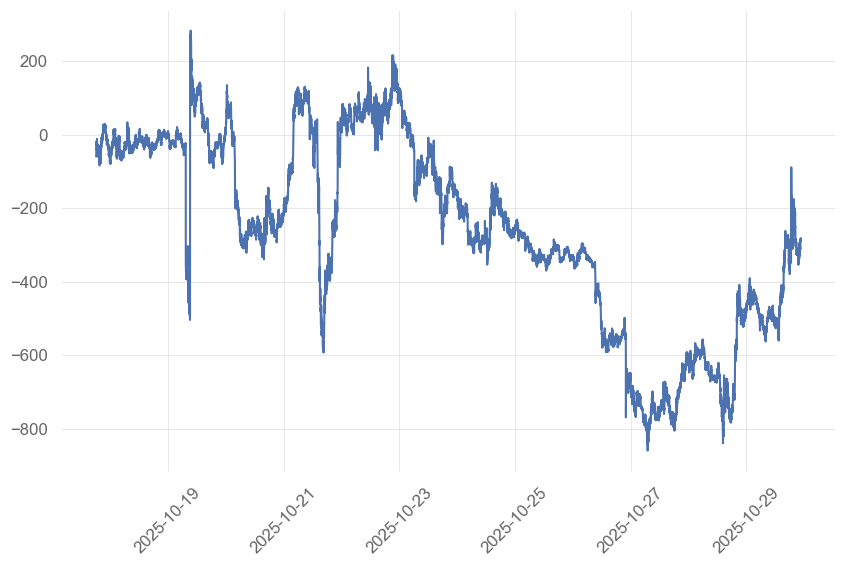

In [18]:
plt.plot(df_dict["BTC"]['unrealized_pnl'])
plt.xticks(rotation=45)
plt.show()

In [19]:
def sum_unrealized_pnls_over_coins(df_dict: dict, tokens: list) -> pd.DataFrame:
    assert len(tokens) >= 2
    sum_pnl = df_dict[tokens[0]]['unrealized_pnl'].add(df_dict[tokens[1]]['unrealized_pnl'], fill_value=0)
    for idx in range(2, len(tokens)):
        sum_pnl = sum_pnl.add(df_dict[tokens[idx]]['unrealized_pnl'], fill_value=0)
    return sum_pnl

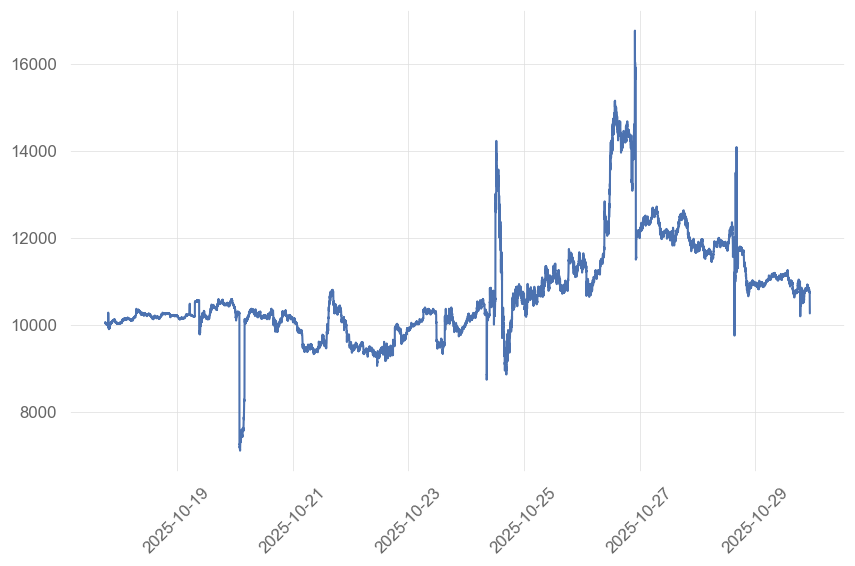

In [20]:
# plt.plot(sum_unrealized_pnls_over_coins(df_dict=df_dict, tokens=tokens))
plt.plot(10e3-sum_unrealized_pnls_over_coins(df_dict=df_dict, tokens=tokens))
plt.xticks(rotation=45)
plt.show()

In [21]:
def get_hyperliquid_history(coin: str, start_dt: datetime, end_dt: datetime = None):
    # convert to milliseconds
    start_ms = int(start_dt.timestamp() * 1000)
    end_ms = int(end_dt.timestamp() * 1000) if end_dt else None

    payload = {
        "type": "fundingHistory",
        "coin": coin,
        "startTime": start_ms
    }
    if end_ms is not None:
        payload["endTime"] = end_ms

    url = "https://api.hyperliquid.xyz/info"
    resp = requests.post(url, json=payload)
    resp.raise_for_status()
    data = resp.json()
    return data  # list of dicts with keys: coin, fundingRate, premium, time


coin = "BTC"
start_dt = datetime(2025, 10, 1)
end_dt   = datetime(2025, 10, 10)
history = get_hyperliquid_history(coin, start_dt, end_dt)
for rec in history:
    # convert time
    t = datetime.fromtimestamp(rec["time"] / 1000.0)
    print(f"{t} | fundingRate={rec['fundingRate']} | premium={rec['premium']}")

2025-10-01 00:00:00.054000 | fundingRate=0.0000125 | premium=-0.0001008392
2025-10-01 01:00:00.012000 | fundingRate=0.0000125 | premium=-0.000051898
2025-10-01 02:00:00.068000 | fundingRate=0.0000125 | premium=-0.0000634535
2025-10-01 03:00:00.008000 | fundingRate=0.0000125 | premium=-0.0000849831
2025-10-01 04:00:00.041000 | fundingRate=0.0000125 | premium=-0.000073454
2025-10-01 05:00:00.031000 | fundingRate=0.0000125 | premium=-0.0000168753
2025-10-01 06:00:00.020000 | fundingRate=0.0000125 | premium=0.0000273985
2025-10-01 07:00:00.030000 | fundingRate=0.0000125 | premium=0.0001572762
2025-10-01 08:00:00.021000 | fundingRate=0.0000125 | premium=0.0001213027
2025-10-01 09:00:00.045000 | fundingRate=0.0000125 | premium=0.0000148641
2025-10-01 10:00:00.081000 | fundingRate=0.0000125 | premium=-0.0000047901
2025-10-01 11:00:00.109000 | fundingRate=0.0000125 | premium=-0.0001091017
2025-10-01 12:00:00.038000 | fundingRate=0.0000125 | premium=-0.0002240777
2025-10-01 13:00:00.083000 | fu